In [1]:
import sys
sys.path.append('../')

import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as m_colors
import seaborn as sns
import pandas as pd
import string
from tqdm.auto import trange
import scipy
import scipy.stats as stats

from src.util import (complexity, 
                      informativity,
                      letter_subplots,
                      degree_of_convexity_cielab)

from src.colorconv import ConvexCluster
from src.voronoicluster import VoronoiCluster

from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

sns.set(context='paper', 
        style='ticks', 
        font_scale=1.1,
        font='serif',
        )

In [2]:
def generate_labels(N, c=0.1):
    a = VoronoiCluster(X=np.zeros((10, 41)),
                        d=60,
                        N=N,
                        s=0,
                        c=0.00001,
                        coords=cielab_list,
                        reverse_labels=cielab_dict_r,
                        p=p_m,
                        i=10000)
    labels = a.run()
    labels = np.vstack((labels[-1, :], labels[:-1, :]))
    labels = np.hstack((labels[:, -1][:, np.newaxis], labels[:, :-1]))

    # here, the labels are random integers corresponding to the unique category
    # i want them to start with one at the top left corner of the matrix, and end
    # with N at the bottom right corner 
    # NB: labels that are nan should be kept as nan
    new_labels = np.zeros_like(labels)
    current_label = 1
    label_map = {}

    for j in range(labels.shape[1]):  # iterate over columns
        for i in range(labels.shape[0]):  # iterate over rows
            if np.isnan(labels[i, j]):
                new_labels[i, j] = np.nan
            else:
                if labels[i, j] not in label_map:
                    label_map[labels[i, j]] = current_label
                    current_label += 1
                new_labels[i, j] = label_map[labels[i, j]]

    return new_labels


In [3]:
# def hue_based(n_categ=10):

#     system = np.zeros((10, 41))

#     # divide this matrix into 10 equally spaced columns and fill from 0 to n_categ
    
#     column_width = 41 // n_categ

#     # now fill each column with numbers from 0 to n_categ
#     for i in range(n_categ):
#         system[:, i*column_width:(i+1)*column_width] = i
    
#     # fill everything in the first and the last row with na except for item at position 0
#     system[0, 1:] = np.nan
#     system[-1, 1:] = np.nan

#     return system


In [4]:
def c_i(lgs, pU_m, p_m):
    '''
    Function to compute the complexity and accuracy for a set of p(w|m)
    '''
    c = []
    i = []

    for lg in lgs:
        c.append(complexity(lg, p_m))
        i.append(informativity(lg, pU_m, p_m))

    return c, i


In [5]:
def compute_pU_m_d(sigma, coords_correct):
    pU_m_d = np.zeros((len(coords_correct), len(coords_correct)))
    
    for i_, i in enumerate(coords_correct):
        for j_, j in enumerate(coords_correct):
            d = np.exp(- (1 / (2 * sigma ** 2)) * np.linalg.norm(np.array(i) - np.array(j))**2)
            pU_m_d[i_, j_] = d
    
    pU_m_d /= pU_m_d.sum(axis=1)[:, np.newaxis]
    
    return pU_m_d

In [6]:
def _ib(p_x, p_y_x, gamma, init, num_iter=100, temperature = 1):
    """ Find encoder q(Z|X) to minimize J = I[X:Z] - gamma * I[Y:Z].
    
    Input:
    p_x : Distribution on X, of shape X. (p(m))
    p_y_x : Conditional distribution on Y given X, of shape X x Y.
    gamma : A non-negative scalar value.
    Z : Support size of Z.

    Output: 
    Conditional distribution on Z given X, of shape X x Z.

    """
    # Randomly initialize the conditional distribution q(z|x)
    q_z_x = init #scipy.special.softmax(np.random.randn(X, Z), -1) # shape X x Z
    p_y_x = p_y_x[:, None, :] # shape X x 1 x Y
    p_x = p_x[:, None] # shape X x 1

    # Blahut-Arimoto iteration to find the minimizing q(z|x)
    for _ in range(num_iter):
        q_xz = p_x * q_z_x # Joint distribution q(x,z), shape X x Z
        q_z = q_xz.sum(axis=0, keepdims=True) # Marginal distribution q(z), shape 1 x Z
        q_y_z = ((q_xz / q_z)[:, :, None] * p_y_x).sum(axis=0, keepdims=True) # Conditional decoder distribution q(y|z), shape 1 x Z x Y
        d = ( 
            scipy.special.xlogy(p_y_x, p_y_x)
            - scipy.special.xlogy(p_y_x, q_y_z) # negative KL divergence -D[p(y|x) || q(y|z)]
        ).sum(axis=-1) # expected distortion over Y; shape X x Z
        q_z_x = scipy.special.softmax((np.log(q_z) - gamma*d)/temperature, axis=-1) # Conditional encoder distribution q(z|x) = 1/Z q(z) e^{-gamma*d}

    return q_z_x

In [7]:
def compute_ib_curve(p_m, pU_m_d, p_w_m, beta_range=(1, 0.00001, 100), num_iter=1):
    """
    Compute the IB curve and rotated WCS data
    """
    # Define the beta range
    betas = np.geomspace(*beta_range)
    
    # Compute the IB curve
    opt_lg = []
    for beta in betas:
        opt_lg.append(_ib(p_m.squeeze(), pU_m_d, beta, 
                          np.eye(p_m.shape[0]), num_iter=num_iter))
    
    # Compute original capacity and information
    c, i = c_i(p_w_m, pU_m_d, p_m)
    
    # Compute IB curve based on the optimal lg values
    ib_curve_ = c_i(opt_lg, pU_m_d, p_m)
    
    # Return results as a dictionary
    return {
        'opt_lg': opt_lg,
        'c': c,
        'i': i,
        'ib_curve': ib_curve_
    }


In [8]:
with open('../data/pU_M.pkl', 'rb') as f:
    pU_m = pickle.load(f)

with open('../data/pM.pkl', 'rb') as f:
    p_m = pickle.load(f)

with open('../data/wcs_encoders.pkl', 'rb') as f:
    p_w_m = pickle.load(f)

with open('../data/IB_color_naming.pkl', 'rb') as f:
    ib = pickle.load(f)

In [9]:
# unpickle chip dict
with open('../data/chip_dict.pkl', 'rb') as f:
    chip_dict = pickle.load(f)

# unpickle sielab_dict
with open('../data/cielab_dict.pkl', 'rb') as f:
    cielab_dict = pickle.load(f)   

# unpickle rgb_dict
with open('../data/rgb_dict.pkl', 'rb') as f:
    rgb_dict = pickle.load(f)

# unpickle languages
with open('../data/lg_color.pkl', 'rb') as f:
    lg_color = pickle.load(f)

In [10]:
# flat prior
p_m_u = np.ones(330) / 330
p_m_u = p_m_u[:, None]

In [11]:
# compute the pU_m_d by hand

cielab_coords = pd.read_csv('../data/raw/cnum-vhcm-lab-new.txt', sep='\t')
coords_correct = cielab_coords.sort_values(by='#cnum')[['L*', 'a*', 'b*']].values.tolist()

pU_m_d = np.zeros((330, 330))
sigma = 8

for i_, i in enumerate(coords_correct):
    for j_, j in enumerate(coords_correct):
        d = np.exp( - (1 / (2 * sigma ** 2)) * np.linalg.norm(np.array(i) - np.array(j)) ** 2)
        pU_m_d[i_, j_] = d

pU_m_d /= pU_m_d.sum(axis=1)[:,np.newaxis]

In [12]:
for lg in lg_color:
    lg_color[lg] = np.where(lg_color[lg] == -1, np.nan, lg_color[lg])

In [13]:
# Constants
ROWS = [string.ascii_uppercase[i] for i in range(10)]  # ['A', 'B', ..., 'J']

# Load WCS data
WCS_CNUM_FILE = '../data/raw/chip.txt'  # Replace with actual path to chip.txt
WCS_CNUMS = pd.read_csv(WCS_CNUM_FILE, delimiter='\t', header=None).values

# Create mapping between chip numbers and coordinates
CNUMS_WCS_COR = dict(zip(
    WCS_CNUMS[:, 0],  # Chip number
    [(ROWS.index(WCS_CNUMS[cnum - 1, 1]), WCS_CNUMS[cnum - 1, 2]) for cnum in WCS_CNUMS[:, 0]]  # (row, column)
))

# Build DataFrame for fast lookups
DF = pd.DataFrame({'cnum': np.arange(1, 331)})
DF['x'] = DF['cnum'].apply(lambda x: CNUMS_WCS_COR[x][0])
DF['y'] = DF['cnum'].apply(lambda x: CNUMS_WCS_COR[x][1])
DF.set_index(['x', 'y'], inplace=True)

def ind2cnum(x, y):
    """
    Convert location in the WCS palette to chip number.
    Example: ind2cnum(2, 22) returns 100.
    """
    return DF.loc[x, y]['cnum']

In [14]:
def clean_partition(partition):
    """
    Normalizes the values in the partition to sequential integers (0 to voc_size - 1),
    ignoring NaN values.
    """
    unique_vals = np.unique(partition[~np.isnan(partition)])  # Ignore NaN for unique values
    mapping = {val: idx for idx, val in enumerate(unique_vals)}
    # Vectorize the mapping, explicitly checking for NaN
    return np.vectorize(lambda x: mapping.get(x, -1))(partition)

def binary(partition):
    """
    Converts a partition matrix into a one-hot encoded matrix.
    Handles special cases for outlier chips.
    """
    # Normalize the partition
    # partition = clean_partition(partition)

    # Determine vocabulary size
    voc_size = len(np.unique(partition[~np.isnan(partition)])) + 1  # Exclude NaN

    # Initialize the encoder matrix
    encoder = np.zeros((330, voc_size))

    # Fill in the one-hot encoding
    for i in range(partition.shape[0]):  # Loop through rows
        for j in range(partition.shape[1]):  # Loop through columns
            if np.isnan(partition[i, j]):  # Skip NaN values
                pass
            else:
                # chip_index = int(ind2cnum(i + 1, j) - 1)  # Convert to chip index
                chip_index = int(ind2cnum(i, j))  # Convert to chip index
                word_index = int(partition[i, j])  # Use normalized value as index
                encoder[chip_index - 1, word_index] = 1.0

    # # Handle the outlier chips
    # encoder[140, partition[0, 0]] = 1.0  # Assign value from (1, 0)
    # encoder[88, partition[7, 0]] = 1.0   # Assign value from (8, 0)

    # Validate the encoding
    # if not np.all(np.sum(encoder, axis=1) == 1.0):
    #     raise ValueError("The probability distribution is not normalized!")

    return encoder

In [15]:
def binary_p(partitions):
    """
    Converts a list of partition matrices into a probabilistic binary encoding.
    Each chip's encoding represents the proportion of labels at that chip across all partitions.
    """
    # Determine vocabulary size from all partitions
    voc_size = max(len(np.unique(partition[~np.isnan(partition)])) for partition in partitions) + 1  # Exclude NaN

    # Initialize the encoder matrix
    encoder = np.zeros((330, voc_size))

    # Process each partition
    for partition in partitions:
        for i in range(partition.shape[0]):  # Loop through rows
            for j in range(partition.shape[1]):  # Loop through columns
                if not np.isnan(partition[i, j]):  # Skip NaN values
                    chip_index = int(ind2cnum(i, j))  # Convert to chip index
                    word_index = int(partition[i, j])  # Use normalized value as index
                    encoder[chip_index - 1, word_index] += 1.0

    # Normalize to get proportions for each label
    encoder /= len(partitions)

    return encoder


In [16]:
cielab_dict_ = {k: v for k, v in cielab_dict.items() if k[0] in range(-1, 9) and k[1] in range(-1, 41)}

# reverse keys and values in cielab_dict_
cielab_dict_r = {v: k for k, v in cielab_dict_.items()}

# convert cielab_dict_ to a list of tuples ordered from (0, 0) to (8, 40)
cielab_list = [cielab_dict_[k] for k in sorted(cielab_dict_.keys())]

In [17]:
def gen_convex(N, uniform=False):
    if uniform:
        prior = p_m_u.squeeze()
    else:
        prior = p_m.squeeze()

    S = np.random.uniform(0.1, 1)
    C = np.random.uniform(0.0001, 0.1)
    a = ConvexCluster(X = np.zeros((10, 41)), 
                      d = 10, 
                      N = N, 
                      s = S, 
                      c = C,
                      coords = cielab_list,
                      reverse_labels = cielab_dict_r,
                      p=p_m.squeeze())
    labels = a.run()
    # labels = np.hstack((labels[:, -1][:, np.newaxis], labels[:, :-1]))
    # move the last row on top
    labels = np.vstack((labels[-1, :], labels[:-1, :]))
    # move the last column first
    labels = np.hstack((labels[:, -1][:, np.newaxis], labels[:, :-1]))
    try:
        return binary(labels), labels, a.degree_of_convexity(), S, C
    except:
        return None

Text(0.5, 1.0, 'c = 0.82')

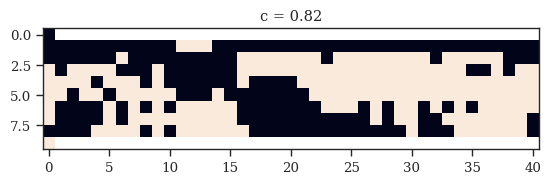

In [18]:
b_l, l, conv, S_, C_ = gen_convex(N=2)

plt.imshow(l)
plt.title(f'c = {conv:.2f}')

In [19]:
convex_lgs = [gen_convex(N=np.random.randint(3, 16), 
                         uniform=False) ## !! uniform false !!
                         for _ in trange(10000)]

  0%|          | 0/10000 [00:00<?, ?it/s]

In [20]:
convex_lgs = [i for i in convex_lgs if i is not None]
# convex_lgs_u = [i for i in convex_lgs_u if i is not None]
len(convex_lgs)

9990

In [21]:
c_c = []
i_c = []

for lg in [_[0] for _ in convex_lgs]:
    c_c.append(complexity(lg, p_m))
    i_c.append(informativity(lg, pU_m_d, p_m))

In [22]:
c_n = []
i_n = []

for lg in [binary(i) for i in lg_color.values()]:
    c_n.append(complexity(lg, p_m))
    i_n.append(informativity(lg, pU_m_d, p_m))

In [23]:
IB_c = compute_ib_curve(p_m,
                        pU_m_d, 
                        [_[0] for _ in convex_lgs], 
                        beta_range=(100, 0.00001, 100), 
                        num_iter=1)

In [24]:
with open('../data/ib_curve.pkl', 'wb') as f:
    pickle.dump(IB_c['ib_curve'], f)

In [25]:
c, i = c_i(IB_c['opt_lg'], pU_m, p_m)

In [26]:
# make a function that return the informativity value given a complexity value based on c and i
def infor_c(c, i, c_):
    return i[np.argmin(np.abs(np.array(c) - c_))]

In [27]:
# now compute the distance between the closest opt language and convex languages
distances = []

for c_, i_ in zip(c_c, i_c):
    distances.append((i_ - infor_c(c, i, c_))**2)

In [28]:
conv = np.array([_[2] for _ in convex_lgs])

In [29]:
# now do the same for the WCS languages

distances_wcs = []

for c_, i_ in zip(c_n, i_n):
    distances_wcs.append((i_ - infor_c(c, i, c_))**2)

convexity_values = degree_of_convexity_cielab(np.array([lg_color[lg] for lg in list(lg_color.keys())]), 
                                              cielab_dict_, cielab_list)
categories_values = [len(np.unique(lg_color[grid])) - 1 for grid in lg_color]

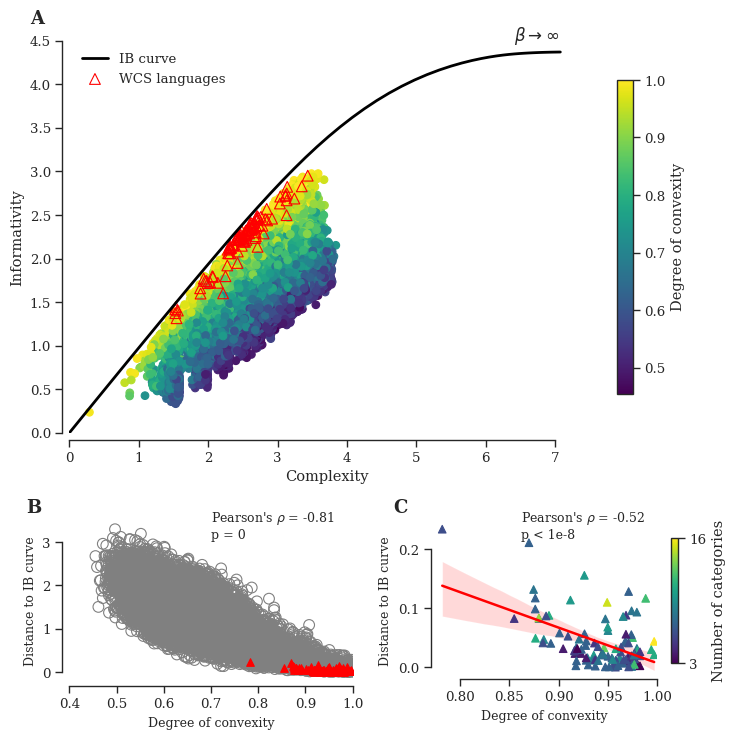

In [74]:
# Create a helper function to format p-value automatically
def format_p(p):
    if p == 0:
        return "p = 0"
    n = int(np.floor(np.log10(p)))
    return f"p < 1e{n}"

# Create a GridSpec for the layout: top plot spans both columns
fig = plt.figure(figsize=(7.5, 7.5))
gs = fig.add_gridspec(2, 2, height_ratios=[2.5, 1])  # 2 rows, 2 columns with different heights

# SUBPLOT A
ax1 = fig.add_subplot(gs[0, :])  # Span the entire top row
ax1.plot(IB_c['ib_curve'][0], IB_c['ib_curve'][1], linestyle='-', 
         color='black', linewidth=2, label='IB curve')
scatter1 = ax1.scatter(c_c, 
            i_c, 
            s=30,
            c=[_[2] for _ in convex_lgs],
            norm=m_colors.Normalize(vmin=min([_[2] for _ in convex_lgs]), 
                                    vmax=1),
            cmap='viridis')
scatter1.set_rasterized(True)
ax1.scatter(c_n, 
            i_n,
            color='red',
            s=60,
            label='WCS languages',
            marker='^',
            facecolors='none',
            alpha=1)
cbar1 = fig.colorbar(scatter1, ax=ax1, shrink=0.8, label='Degree of convexity')
ax1.set_xlabel('Complexity')
ax1.set_ylabel('Informativity')
ax1.set_xlim(0, None)
ax1.set_ylim(0, 4.5)
# cbar1 = fig.colorbar(scatter1, ax=ax1, shrink=0.8, label='Degree of convexity')
ax1.legend(loc='upper left', frameon=False)
sns.despine(ax=ax1, 
            offset=5, 
            trim=True
            )
ax1.text(-0.05, 1.08, 'A', transform=ax1.transAxes, fontsize=13, 
         fontweight='bold', va='top', ha='right')
## add \beta --> infinity on the top right corner
ax1.text(0.95, 1, '$\\beta \\rightarrow \\infty$', 
         fontsize=12, transform=ax1.transAxes, ha='right')

# SUBPLOT B
ax2 = fig.add_subplot(gs[1, 0])
scatter2 = ax2.scatter(conv, distances, color='grey', alpha=1, s=60, facecolors='none')
scatter2.set_rasterized(True)
ax2.scatter(convexity_values, distances_wcs, color='red', marker='^', s=30)
r1, p1 = stats.pearsonr(conv, distances)
ax2.text(0.5, 0.9, f"Pearson's $\\rho$ = {r1:.2f}\n" + format_p(p1), 
         fontsize=9, transform=ax2.transAxes)
ax2.set_xlabel('Degree of convexity', fontsize=9)
ax2.set_ylabel('Distance to IB curve', fontsize=9)
ax2.set_xlim(0.4, 1)
sns.despine(ax=ax2, 
            offset=5, 
            trim=True
            )
ax2.text(-0.1, 1.15, 'B', transform=ax2.transAxes, fontsize=13, 
         fontweight='bold', va='top', ha='right')

# SUBPLOT C
ax3 = fig.add_subplot(gs[1, 1])
sns.regplot(x=convexity_values, y=distances_wcs, 
            scatter=False, color='red', ax=ax3)
scatter = ax3.scatter(convexity_values, distances_wcs, 
                      c=categories_values, alpha=1, s=30, cmap='viridis',
                      marker='^',
                      norm=plt.Normalize(vmin=3, vmax=16))
cbar = fig.colorbar(scatter, ax=ax3, label='Number of categories', shrink=0.8, ticks=[3, 16])
r2, p2 = stats.pearsonr(convexity_values, distances_wcs)
ax3.text(0.4, 0.9, f"Pearson's $\\rho$ = {r2:.2f}\n" + format_p(p2), 
         fontsize=9, transform=ax3.transAxes)
ax3.set_xlabel('Degree of convexity', fontsize=9)
ax3.set_ylabel('Distance to IB curve', fontsize=9)
ax3.set_ylim(-0.02, None)
ax3.set_xlim(0.77, 1)
sns.despine(ax=ax3, 
            offset=0, 
            trim=True
            )
ax3.text(-0.1, 1.15, 'C', transform=ax3.transAxes, fontsize=13, 
         fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.savefig('../figures/Figure_3s.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [31]:
# compute correlation between convexity and complexity and informativity

r_c, p_c = stats.pearsonr(conv, c_c)
r_i, p_i = stats.pearsonr(conv, i_c)

print(f'Correlation between convexity and complexity: {r_c:.2f} (p = {p_c:.3f})')
print(f'Correlation between convexity and informativity: {r_i:.2f} (p = {p_i:.3f})')


Correlation between convexity and complexity: -0.07 (p = 0.000)
Correlation between convexity and informativity: 0.54 (p = 0.000)


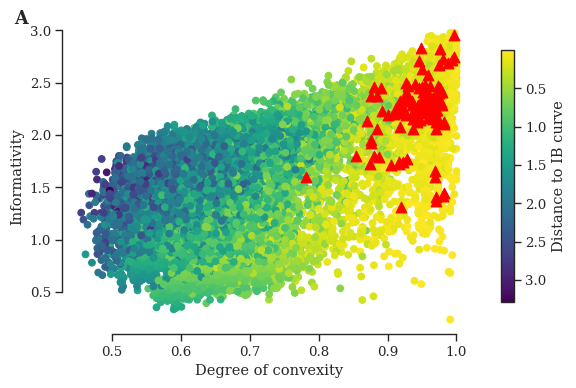

In [32]:
# plot informativeness and convexity as trade-off

fig, axes = plt.subplots(1, 1, figsize=(6, 4))
letter_subplots()
# sc = axes.scatter(conv, 
#                   i_c, 
#                   c=[_[2] for _ in convex_lgs],
#                   norm=m_colors.Normalize(vmin=min([_[2] for _ in convex_lgs]), 
#                                           vmax=1),
#                   cmap='viridis')
# color by complexity
sc = axes.scatter(conv, 
                  i_c, 
                  c=distances,
                  norm=m_colors.Normalize(vmin=min(distances), 
                                          vmax=max(distances)),
                  cmap='viridis_r')
# add wcs languages
axes.scatter(convexity_values, 
             i_n, 
             c='red', 
             s=60,
             label='WCS languages',
             marker='^',
             facecolors='none',
             alpha=1)
cbar = fig.colorbar(sc, ax=axes, shrink=0.8, label='Distance to IB curve')
cbar.ax.invert_yaxis()
axes.set_xlabel('Degree of convexity')
axes.set_ylabel('Informativity')
sns.despine(ax=axes, 
            trim=True)
plt.tight_layout()
plt.show()

In [33]:
# generate a dataset of attested and unnattested systems with their convexity degree, complexity, informativity, and see which factor is better predictor using a random forest

# import pandas as pd
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import mean_squared_error

# prepare the dataset
data = []

# 103 attested languages + 1000 artificial languages
crv = IB_c['ib_curve']

# add distance to IB curve for each language (as horizontal distance, i.e. find language with the related informativity value and compute the distance in complexity)
distances_ = []
for c_, i_ in zip(c_n, i_n):
    idx = np.argmin(np.abs(crv[1] - i_))
    distance_IB = np.abs(c_ - crv[0][idx])
    distances_.append(distance_IB)

# same for convex languages
distances_conv = []
for c_, i_ in zip(c_c, i_c):
    idx = np.argmin(np.abs(crv[1] - i_))
    distance_IB = np.abs(c_ - crv[0][idx])
    distances_conv.append(distance_IB)

for c_, i_, conv_, d_ in zip(c_n, i_n, convexity_values, distances_):
    data.append({'complexity': c_, 
                 'informativity': i_, 
                 'convexity': conv_,
                 'distance': d_, 
                 'attested': 1})
    
for c_, i_, conv_, d_ in zip(c_c, i_c, conv, distances_conv):
    data.append({'complexity': c_, 
                 'informativity': i_, 
                 'convexity': conv_, 
                'distance': d_,
                 'attested': 0})
    
df = pd.DataFrame(data)
df.head()

,complexity,informativity,convexity,distance,attested
0,2.422564,1.948877,0.876268,0.465482,1
1,2.589309,2.289434,0.935724,0.237070,1
2,2.823579,2.449942,0.890207,0.285261,1
3,2.721539,2.467593,0.962028,0.183221,1
4,2.628209,2.370877,0.930126,0.089892,1


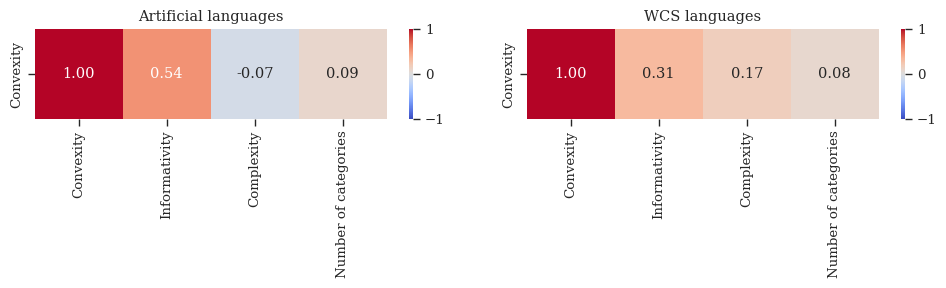

In [34]:
# Plot correlation matrix with convexity as rows only
fig, ax = plt.subplots(1, 2, figsize=(10, 3))

# Artificial languages
df_artificial = pd.DataFrame({
    'Convexity': conv,
    'Informativity': i_c,
    'Complexity': c_c,
    'Number of categories': [len(np.unique(_[1][~np.isnan(_[1])])) for _ in convex_lgs],
    # 'Distance': distances
})
sns.heatmap(df_artificial.corr().loc[['Convexity']], annot=True, 
            fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, ax=ax[0])
ax[0].set_title('Artificial languages')

# WCS languages
df_wcs = pd.DataFrame({
    'Convexity': convexity_values,
    'Informativity': i_n,
    'Complexity': c_n,
    'Number of categories': categories_values,
    # 'Distance': distances_wcs
})
sns.heatmap(df_wcs.corr().loc[['Convexity']], annot=True, 
            fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, ax=ax[1])
ax[1].set_title('WCS languages')

plt.tight_layout()
plt.show()

In [50]:
X_cols = ['convexity', 'complexity', 'informativity']
all_results = []

y = df['distance']

for col in X_cols:
    X = df[[col]]
    X_scaled = MinMaxScaler().fit_transform(X)
    model = RandomForestRegressor(random_state=42)
    
    # ---- Regular (true) predictor ----
    scores_true = cross_val_score(model, X_scaled, y, cv=20, 
                                  scoring='neg_mean_squared_error', 
                                  n_jobs=-1)
    for s in scores_true:
        all_results.append({'feature': col, 'mse': -s, 'type': 'true'})
    
    # ---- Random baseline (shuffled X) ----
    X_shuffled = np.random.permutation(X_scaled)
    scores_rand = cross_val_score(model, X_shuffled, y, cv=20, 
                                  scoring='neg_mean_squared_error',
                                  n_jobs=-1)
    for s in scores_rand:
        all_results.append({'feature': col, 'mse': -s, 'type': 'random'})

# Create DataFrame
results_df = pd.DataFrame(all_results)

# Optional summary
print(results_df.groupby(["feature", "type"])['mse'].agg(['mean', 'std']))

                          mean       std
feature       type                      
complexity    random  0.262158  0.030213
              true    0.181305  0.024242
convexity     random  0.267408  0.032907
              true    0.087378  0.006372
informativity random  0.267914  0.032816
              true    0.186337  0.017330


In [51]:
# rename complexity to simplicity and informativity to informativeness
results_df['feature'] = results_df['feature'].replace({
    'complexity': 'simplicity',
    'informativity': 'informativeness'
})

In [68]:
# Ensure categorical x is clean string values only
results_df['feature'] = results_df['feature'].astype(str)

# Ensure only known features are included
X_cols = ['informativeness', 'simplicity', 'convexity', 'distance_IB']
results_df = results_df[results_df['feature'].isin(X_cols)]

/var/folders/1c/pphtjl397rnbdcp94xmwzkqr0000gn/T/ipykernel_13718/981209852.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.pointplot(
/Users/alexeykoshevoy/.pyenv/versions/3.11.2/lib/python3.11/site-packages/matplotlib/axes/_base.py:2503: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)


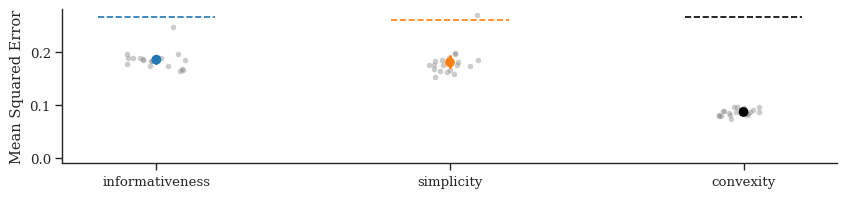

In [75]:
# Define a color per feature (consistent across plots)
# palette = dict(zip(X_cols, sns.color_palette("Set2", n_colors=len(X_cols))))
palette = {
    'informativeness': '#1f77b4',   # matplotlib blue
    'simplicity': '#ff7f0e',      # matplotlib orange
    'convexity': '#000000',       # black
    'distance_IB': '#d62728'      # matplotlib red
}


plt.figure(figsize=(10, 2))
# add observed values as individual points
sns.stripplot(
    data=results_df.query("type == 'true'"),
    x='feature',
    y='mse',
    order=X_cols,
    color='grey',
    size=4,
    alpha=0.4,
    jitter=True,
    # position to the back
    zorder=-1
)
# Plot pointplot for true models
sns.pointplot(
    data=results_df.query("type == 'true'"),
    x='feature',
    y='mse',
    order=X_cols,
    ci=95,
    palette=palette
)

# Add average of random baseline as horizontal line in matching color
for feature in X_cols:
    mean_rand = results_df.query(f"feature == '{feature}' and type == 'random'")['mse'].mean()
    color = palette[feature]
    plt.hlines(
        mean_rand,
        xmin=X_cols.index(feature) - 0.2,
        xmax=X_cols.index(feature) + 0.2,
        colors=color,
        linestyles='dashed',
        label='Random baseline' if feature == X_cols[0] else ""
    )

plt.ylabel('Mean Squared Error')
plt.xlabel('')
sns.despine()
plt.ylim(-0.01, None)
# plt.legend(frameon=False)
plt.savefig('../figures/Figure_5.pdf', dpi=300, bbox_inches='tight')
plt.show()